# Dynamic Credit Risk and Loan Pricing Using Interest-Rate Monte Carlo Simulation

## Introduction

Credit risk modeling is traditionally centered on estimating the probability that a borrower will default and the resulting financial loss. Key measures such as **Probability of Default (PD)**, **Loss Given Default (LGD)**, and **Exposure at Default (EAD)** provide a foundation for estimating expected credit losses. However, a loan portfolio is exposed to more than borrower-specific characteristics. Changes in the broader interest-rate environment can affect funding costs, loan payments, borrower affordability, default probabilities, and ultimately the profitability of lending products.

This project develops a **Monte Carlo-based credit-risk and loan-pricing framework** that combines machine learning, stochastic interest-rate modeling, and portfolio loss simulation. Synthetic loan data are first generated to represent borrower characteristics such as income, credit score, debt-to-income ratio, loan amount, and maturity. A logistic regression model is then used to estimate borrower-level Probability of Default (PD).

To incorporate uncertainty in future interest rates, the project uses the **Vasicek interest-rate model**, a stochastic process that represents interest rates through mean reversion and random shocks:

$$
dr_t = \kappa(\theta-r_t)\,dt+\sigma\,dW_t
$$

The simulated interest-rate scenarios are then connected to borrower credit risk. Higher interest rates can increase debt-service burdens and potentially increase the probability of default. Monte Carlo simulation is subsequently used to generate thousands of possible portfolio outcomes by simultaneously considering default events, stochastic LGD, loan exposure, and different interest-rate environments.

The resulting simulations produce a **distribution of potential portfolio credit losses**, rather than a single expected-loss estimate. From this distribution, the project calculates metrics such as **Expected Loss, Value at Risk (VaR), and Expected Shortfall**.

Finally, the framework connects credit risk to loan-product pricing. Different loan interest rates are evaluated by considering the trade-off between interest income, funding costs, and expected credit losses. This demonstrates how quantitative risk modeling can support questions such as:

**How might changes in interest rates affect borrower default risk, portfolio losses, and the economics of a loan product?**

## Project Objectives

The main objectives are to:

* Build a borrower-level Probability of Default model.
* Simulate future interest-rate paths using the Vasicek model.
* Incorporate interest-rate scenarios into dynamic credit risk.
* Simulate stochastic PD, LGD, and EAD.
* Generate a Monte Carlo distribution of portfolio credit losses.
* Calculate Expected Loss, VaR, and Expected Shortfall.
* Examine the relationship between interest rates and credit losses.
* Evaluate the potential profitability of different loan interest-rate assumptions.
* Demonstrate how machine learning and mathematical finance can be combined in credit-risk analytics.

## Conceptual Framework

The overall framework can be summarized as:

$$
\boxed{
\text{Borrower Characteristics}
\rightarrow
\text{PD Model}
\rightarrow
\text{Interest-Rate Scenarios}
\rightarrow
\text{Monte Carlo Simulation}
\rightarrow
\text{Credit Loss Distribution}
\rightarrow
\text{Loan Pricing Analysis}
}
$$

This project is intended as an **educational MVP rather than a production banking model**. The portfolio data and several relationships are simulated for demonstration purposes. In a production environment, the framework would require historical loan-performance data, validated macroeconomic relationships, calibrated interest-rate models, default-correlation modeling, rigorous model validation, and appropriate regulatory and governance controls.

## Possible Extensions

1. **Use Real Loan Data**

   Replace synthetic data with historical loan-performance data and perform out-of-time validation.

2. **Dynamic PD & Macroeconomic Modeling**

   Model PD as a function of borrower characteristics, interest rates, GDP, inflation, unemployment, and other economic variables:

   $$
   PD_{i,t} = f(X_{i,t}, r_t, \text{Macro Factors}_t)
   $$

3. **Advanced Interest-Rate & Monte Carlo Models**

   Compare Vasicek with CIR or Hull--White and simulate correlated interest-rate and default scenarios.

4. **Stochastic LGD & EAD**

   Allow LGD and EAD to change according to collateral values, borrower behavior, economic conditions, and utilization.

## Install/import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from scipy.stats import norm

# Make results reproducible.
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


We use logistic regression for the first version because it is interpretatble. In credit risk, interpretability is important because you want to understand how borrower variables affect predicted PD.

## Create synthetic loan portfolio

In [2]:
N = 10000

rng = np.random.default_rng(42)

loan_data = pd.DataFrame({
    "loan_id": np.arange(1, N + 1),

    # Borrower's annual income.
    "annual_income": rng.lognormal(
        mean=np.log(500000),
        sigma=0.45,
        size=N
    ),

    # Credit score.
    "credit_score": np.clip(
        rng.normal(680, 55, N),
        300,
        850
    ),

    # Debt-to-income ratio.
    "dti": np.clip(
        rng.normal(0.35, 0.12, N),
        0.05,
        0.90
    ),

    # Loan amount.
    "loan_amount": rng.uniform(50000, 1000000, N),

    # Loan maturity in years.
    "maturity_years": rng.choice(
        [1, 2, 3, 5],
        size=N,
        p=[0.10, 0.20, 0.40, 0.30]
    ),

    # Current market interest rate.
    "market_rate": np.clip(
        rng.normal(0.06, 0.015, N),
        0.02,
        0.12
    )
})

loan_data.head()

,loan_id,annual_income,credit_score,dti,loan_amount,maturity_years,market_rate
0,1,573484.428392,689.695237,0.151016,946032.191407,5,0.041254
1,2,313129.001379,729.451792,0.456945,650941.846711,3,0.067856
2,3,700862.091467,599.025116,0.343036,489540.520934,3,0.066040
3,4,763461.135892,664.308601,0.278011,107604.572417,3,0.064842
4,5,207813.753670,725.603431,0.319902,311865.264499,3,0.075661


We create characteristics that are economically meaningful:

- Higher income $\rightarrow$ generally lower risk
- Higher credit score $\rightarrow$ generally lower risk
- Higher DTI $\rightarrow$ generally higher risk
- Larger exposure $\rightarrow$ larger potential loss
- Maturity $\rightarrow$ affects interest income
- Market rate $\rightarrow$ connects the credit model to interest-rate modeling

## Generate synthetic default outcomes

In [3]:
# Since this is synthetic data, we create a "true" underlying
# probability of default using economically sensible
# relationships.
#
# IMPORTANT:
# In a real project, default would come from historical
# observed loan performance rather than being generated this way.

x1 = (loan_data["credit_score"] - 680) / 50
x2 = (loan_data["dti"] - 0.35) / 0.10
x3 = np.log(loan_data["annual_income"] / 500000)
x4 = (loan_data["market_rate"] - 0.06) / 0.02

# Latent credit-risk score.
logit_pd = (
    -2.7
    - 0.55 * x1
    + 0.65 * x2
    - 0.35 * x3
    + 0.25 * x4
)

# Convert log-odds to probability.
true_pd = 1 / (1 + np.exp(-logit_pd))

# Simulate actual default events.
loan_data["default"] = rng.binomial(
    1,
    true_pd
)

loan_data["true_pd"] = true_pd

print("Default rate:",
      round(loan_data["default"].mean() * 100, 2), "%")

Default rate: 8.87 %


We first create a latent PD relationship:

$$
PD_i = \frac{1}{1 + e^{-z_i}}
$$

This is the logistic function.

The important point is that $PD$ is a probability, while default is an observed event.

For example:

$$
PD = 0.10
$$

doesn't mean the borrower definitely defaults.

It means there is a modeled $10\%$ probability of default.

## Inspect the porfolio

In [4]:
print("Shape:", loan_data.shape)

print("\nMissing values:")
print(loan_data.isnull().sum())

print("\nSummary statistics:")
display(loan_data.describe())

Shape: (10000, 9)

Missing values:
loan_id           0
annual_income     0
credit_score      0
dti               0
loan_amount       0
maturity_years    0
market_rate       0
default           0
true_pd           0
dtype: int64

Summary statistics:


,loan_id,annual_income,credit_score,dti,loan_amount,maturity_years,market_rate,default,true_pd
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5.514541e+05,681.111607,0.351938,525839.392187,3.199700,0.059947,0.088700,0.090407
std,2886.89568,2.636340e+05,55.134775,0.119803,274645.919943,1.327703,0.014987,0.284324,0.085196
min,1.00000,6.937361e+04,466.170761,0.050000,50026.091592,1.000000,0.020000,0.000000,0.001590
25%,2500.75000,3.686442e+05,643.555137,0.270624,285105.294650,2.000000,0.049924,0.000000,0.032694
50%,5000.50000,4.970461e+05,680.499887,0.352194,529703.204725,3.000000,0.059952,0.000000,0.063798
75%,7500.25000,6.698775e+05,718.246827,0.432198,762571.378698,5.000000,0.069926,0.000000,0.119254
max,10000.00000,3.060180e+06,850.000000,0.791901,999913.700597,5.000000,0.120000,1.000000,0.720520


Data quality is part of real credit-risk work. A sophisticated model trained on bad data can still produce bad risk estimates.

## Explore default relationship

,default
credit_band,
<600,18.992806
600-650,13.675602
650-700,8.266129
700-750,5.175820
750+,3.269755


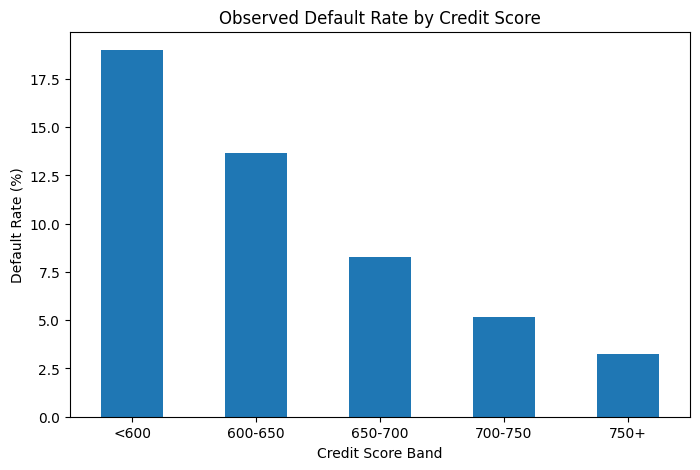

In [5]:
loan_data["credit_band"] = pd.cut(
    loan_data["credit_score"],
    bins=[300, 600, 650, 700, 750, 850],
    labels=[
        "<600",
        "600-650",
        "650-700",
        "700-750",
        "750+"
    ]
)

default_by_score = (
    loan_data
    .groupby("credit_band", observed=True)["default"]
    .mean()
    .mul(100)
)

display(default_by_score)

default_by_score.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Observed Default Rate by Credit Score")
plt.ylabel("Default Rate (%)")
plt.xlabel("Credit Score Band")
plt.xticks(rotation=0)
plt.show()

This gives us basic credit-risk intuition before fitting a model.

##Prepare data for the PD model

In [6]:
# We select borrower characteristics that will be used to
# predict default.

features = [
    "annual_income",
    "credit_score",
    "dti",
    "loan_amount",
    "maturity_years",
    "market_rate"
]

X = loan_data[features]
y = loan_data["default"]

# Split into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 7000
Testing observations: 3000


## Train the PD model

In [7]:
# StandardScaler puts numerical variables on comparable
# scales before regression.

pd_model = Pipeline([
    ("scaler", StandardScaler()),

    ("model", LogisticRegression(
        max_iter=1000
    ))
])

pd_model.fit(X_train, y_train)

print("PD model trained successfully.")

PD model trained successfully.


##Evaluate the PD model

Test AUC: 0.7535


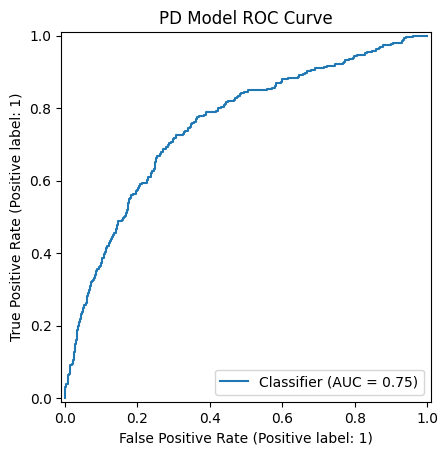

In [8]:
# We generate predicted probabilities rather than simply
# predicted classes.
#
# Credit risk generally cares about the probability itself.

test_pd = pd_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(
    y_test,
    test_pd
)

print(f"Test AUC: {auc:.4f}")

# ROC curve.
RocCurveDisplay.from_predictions(
    y_test,
    test_pd
)

plt.title("PD Model ROC Curve")
plt.show()

AUC measures how well the model separates relatively risky borrowers from relatively safe borrowers.

But don't treat AUC as the only measure of a credit model's quality. Real model validation would also examine:

- calibration
- stability
- population drift
- discriminatory power
- out-of-time performance
- model assumptions

## Generate PD for the entire porfolio

In [9]:
# We now use the trained model to estimate PD for every loan.

loan_data["predicted_pd"] = pd_model.predict_proba(
    loan_data[features]
)[:, 1]

display(
    loan_data[
        [
            "loan_id",
            "credit_score",
            "dti",
            "loan_amount",
            "predicted_pd",
            "default"
        ]
    ].head(10)
)

,loan_id,credit_score,dti,loan_amount,predicted_pd,default
0,1,689.695237,0.151016,946032.191407,0.012536,0
1,2,729.451792,0.456945,650941.846711,0.084595,0
2,3,599.025116,0.343036,489540.520934,0.127441,1
3,4,664.308601,0.278011,107604.572417,0.040831,0
4,5,725.603431,0.319902,311865.264499,0.042243,0
5,6,683.608008,0.474412,926956.215531,0.151474,0
6,7,760.703360,0.437749,603751.715926,0.042533,0
7,8,593.324215,0.334649,375543.423901,0.150425,0
8,9,587.049903,0.213307,286376.029671,0.066582,0
9,10,722.332758,0.221775,157974.176303,0.014693,0


## Introduce the Vasicek interest-rate model

In [10]:
# The Vasicek model is:
#
#   dr = kappa * (theta - r) * dt + sigma * dW
#
# where:
#
# r      = current interest rate
# kappa  = speed of mean reversion
# theta  = long-run interest rate
# sigma  = interest-rate volatility
# dW     = Brownian-motion shock

r0 = 0.06       # Current interest rate = 6%
theta = 0.06    # Long-run rate = 6%
kappa = 0.50    # Mean-reversion speed
sigma = 0.02    # Interest-rate volatility
dt = 1 / 12     # Monthly time step

print("Vasicek parameters:")
print("Initial rate:", r0)
print("Long-run rate:", theta)
print("Mean reversion:", kappa)
print("Volatility:", sigma)

Vasicek parameters:
Initial rate: 0.06
Long-run rate: 0.06
Mean reversion: 0.5
Volatility: 0.02


## Simulate interest-rate paths via Monte Carlo Simulation

In [11]:
# We simulate 1,000 possible interest-rate futures.
#
# Each path represents one possible evolution of interest rates.

n_paths = 1000
n_months = 60

rate_paths = np.zeros(
    (n_paths, n_months + 1)
)

rate_paths[:, 0] = r0

for t in range(1, n_months + 1):

    # Random Brownian-motion shock.
    z = rng.normal(
        0,
        1,
        n_paths
    )

    # Vasicek discretization.
    rate_paths[:, t] = (
        rate_paths[:, t - 1]
        + kappa
        * (theta - rate_paths[:, t - 1])
        * dt
        + sigma
        * np.sqrt(dt)
        * z
    )

# Prevent negative rates for this simplified MVP.
rate_paths = np.maximum(
    rate_paths,
    0.0001
)

print("Rate simulation completed.")

Rate simulation completed.


##Visualize interest-rate scenarios

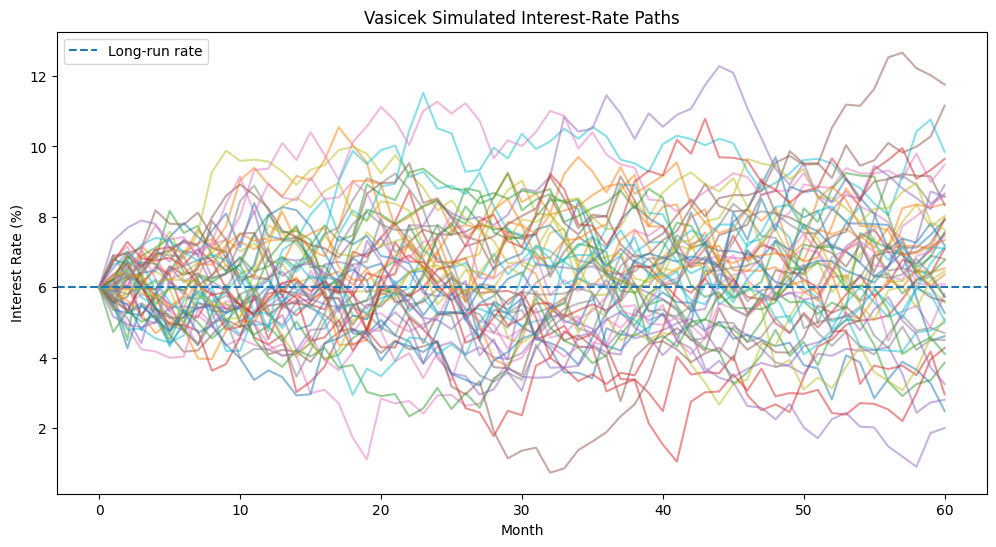

In [12]:
# We plot a sample of simulated paths so we can see the
# uncertainty in future interest rates.

plt.figure(figsize=(12, 6))

for i in range(50):
    plt.plot(
        rate_paths[i] * 100,
        alpha=0.5
    )

plt.axhline(
    theta * 100,
    linestyle="--",
    label="Long-run rate"
)

plt.title("Vasicek Simulated Interest-Rate Paths")
plt.xlabel("Month")
plt.ylabel("Interest Rate (%)")
plt.legend()
plt.show()

So, instead of having a specific interest rate at specific period. We simulate many possible interest-rate paths.

## Connect interest rates to PD

In [13]:
# We now introduce a simplified interest-rate sensitivity:
#
#       stressed_PD = baseline_PD * rate_multiplier
#
# The multiplier increases when rates rise above the current
# 6% level.
#
# This is intentionally simplified for an MVP.
#
# In a production model, this relationship would normally be
# estimated empirically using historical borrower and
# macroeconomic data.

baseline_pd = loan_data["predicted_pd"].values

def rate_adjusted_pd(
    baseline_pd,
    simulated_rate,
    base_rate=0.06,
    sensitivity=4.0
):
    """
    Adjust baseline PD based on the simulated interest rate.

    sensitivity controls how strongly PD responds to rate
    changes.
    """

    rate_shock = simulated_rate - base_rate

    multiplier = np.exp(
        sensitivity * rate_shock
    )

    adjusted_pd = baseline_pd * multiplier

    # PD cannot exceed 100%.
    return np.clip(
        adjusted_pd,
        0,
        0.999
    )

print("Dynamic PD function created.")

Dynamic PD function created.


If:

$$
r_t > 6\%
$$

then:

$$
PD_t
$$

increases.

If:

$$
r_t < 6\%
$$

then the rate-driven adjustment decreases.

##Define LGD

In [14]:
# LGD represents the percentage of exposure lost after default.
#
# Instead of assuming:
#
#       LGD = 40%
#
# for every loan, we introduce uncertainty.
#
# We use a Beta distribution because it naturally produces
# values between 0 and 1.

lgd_alpha = 4
lgd_beta = 6

def simulate_lgd(n):
    """
    Generate stochastic LGD values.
    """
    return rng.beta(
        lgd_alpha,
        lgd_beta,
        n
    )

sample_lgd = simulate_lgd(10000)

print(
    "Average simulated LGD:",
    round(sample_lgd.mean() * 100, 2),
    "%"
)

Average simulated LGD: 40.05 %


The Beta distribution is convenient here because:

$$
0 \leq LGD \leq 1
$$

## Build the Monte Carlo credit-risk engine

In [15]:
# For each Monte Carlo scenario:
#
# 1. Select an interest rate.
# 2. Adjust each borrower's PD.
# 3. Simulate default.
# 4. Simulate LGD.
# 5. Calculate credit loss.
# 6. Aggregate losses across the portfolio.

portfolio_ead = loan_data["loan_amount"].values

n_simulations = 10000

portfolio_losses = np.zeros(n_simulations)

scenario_rates = np.zeros(n_simulations)

for sim in range(n_simulations):

    # Randomly select one month from the simulated
    # interest-rate environment.
    month = rng.integers(
        1,
        n_months + 1
    )

    # Select one simulated interest-rate path.
    path = rng.integers(
        0,
        n_paths
    )

    simulated_rate = rate_paths[
        path,
        month
    ]

    scenario_rates[sim] = simulated_rate

    # Adjust borrower PD according to interest rate.
    stressed_pd = rate_adjusted_pd(
        baseline_pd,
        simulated_rate
    )

    # Simulate whether each borrower defaults.
    defaults = rng.binomial(
        1,
        stressed_pd
    )

    # Simulate recovery severity.
    lgd = simulate_lgd(N)

    # Credit loss for each borrower.
    loan_losses = (
        defaults
        * lgd
        * portfolio_ead
    )

    # Aggregate portfolio loss.
    portfolio_losses[sim] = loan_losses.sum()

print("Monte Carlo simulation completed.")

Monte Carlo simulation completed.


This is the heart of the model:

$$
\boxed{
L^{(s)}
=
\sum_i
D_i^{(s)}
LGD_i^{(s)}
EAD_i
}
$$

for:

$$
s = 1, \ldots, 10{,}000
$$

## Analyzing the loss distribution

In [16]:
# We calculate several important risk statistics.

expected_loss = np.mean(
    portfolio_losses
)

loss_std = np.std(
    portfolio_losses
)

var_95 = np.percentile(
    portfolio_losses,
    95
)

var_99 = np.percentile(
    portfolio_losses,
    99
)

# Expected Shortfall:
# average loss among scenarios exceeding the 95th percentile.
expected_shortfall_95 = np.mean(
    portfolio_losses[
        portfolio_losses >= var_95
    ]
)

print("Expected Loss:")
print(f"₱{expected_loss:,.0f}")

print("\nLoss Standard Deviation:")
print(f"₱{loss_std:,.0f}")

print("\n95% VaR:")
print(f"₱{var_95:,.0f}")

print("\n99% VaR:")
print(f"₱{var_99:,.0f}")

print("\n95% Expected Shortfall:")
print(f"₱{expected_shortfall_95:,.0f}")

Expected Loss:
₱186,232,917

Loss Standard Deviation:
₱15,458,202

95% VaR:
₱212,918,266

99% VaR:
₱225,117,838

95% Expected Shortfall:
₱220,636,076


### Why this matters

**Expected loss answers:** "What is the average credit loss?"

**VaR asks:** "How large can losses become in a high-loss percentile?"

**Expected Shortfall asks:** "When we enter the worst 5\% of scenarios, how large are losses on average?"

##Now visualize the credit-loss distribution

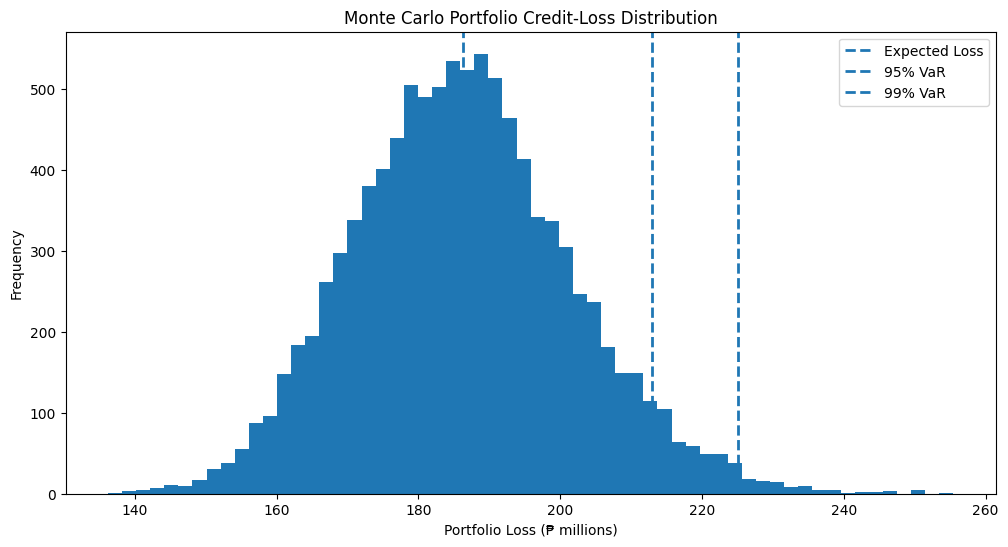

In [17]:
plt.figure(figsize=(12, 6))

plt.hist(
    portfolio_losses / 1_000_000,
    bins=60
)

plt.axvline(
    expected_loss / 1_000_000,
    linestyle="--",
    linewidth=2,
    label="Expected Loss"
)

plt.axvline(
    var_95 / 1_000_000,
    linestyle="--",
    linewidth=2,
    label="95% VaR"
)

plt.axvline(
    var_99 / 1_000_000,
    linestyle="--",
    linewidth=2,
    label="99% VaR"
)

plt.title(
    "Monte Carlo Portfolio Credit-Loss Distribution"
)

plt.xlabel("Portfolio Loss (₱ millions)")
plt.ylabel("Frequency")

plt.legend()
plt.show()

## Calculate expected loss by rate scenario

In [18]:
# We divide simulations into interest-rate buckets and see
# how portfolio losses behave under different rate environments.

results = pd.DataFrame({
    "interest_rate": scenario_rates,
    "portfolio_loss": portfolio_losses
})

results["rate_bucket"] = pd.qcut(
    results["interest_rate"],
    q=5,
    duplicates="drop"
)

rate_loss_summary = (
    results
    .groupby("rate_bucket", observed=True)["portfolio_loss"]
    .agg(
        mean_loss="mean",
        median_loss="median"
    )
)

rate_loss_summary

,mean_loss,median_loss
rate_bucket,,
"(-0.0009, 0.0442]",1.675759e+08,1.680301e+08
"(0.0442, 0.0551]",1.788101e+08,1.787609e+08
"(0.0551, 0.0638]",1.857101e+08,1.856678e+08
"(0.0638, 0.0745]",1.928573e+08,1.924957e+08
"(0.0745, 0.133]",2.062112e+08,2.050731e+08


This allows you to investigate:

$$
\text{Interest Rate} \rightarrow \text{Credit Loss}
$$

## Loan-pricing model

In [19]:
# We define a simplified expected-profit calculation.
#
# Profit =
#
#       Interest Income
#       - Funding Cost
#       - Expected Credit Loss
#
# This is deliberately simplified.
#
# A real lender would also include operating costs, capital
# costs, fees, prepayments, taxes, liquidity costs, etc.

def calculate_expected_profit(
    loan_rate,
    funding_rate,
    loan_amount,
    pd,
    lgd
):

    interest_income = (
        loan_rate
        * loan_amount
    )

    funding_cost = (
        funding_rate
        * loan_amount
    )

    expected_credit_loss = (
        pd
        * lgd
        * loan_amount
    )

    profit = (
        interest_income
        - funding_cost
        - expected_credit_loss
    )

    return {
        "interest_income": interest_income,
        "funding_cost": funding_cost,
        "expected_credit_loss": expected_credit_loss,
        "profit": profit
    }

example = calculate_expected_profit(
    loan_rate=0.12,
    funding_rate=0.07,
    loan_amount=1_000_000,
    pd=0.05,
    lgd=0.40
)

example

{'interest_income': 120000.0,
 'funding_cost': 70000.0,
 'expected_credit_loss': 20000.000000000004,
 'profit': 29999.999999999996}

##Testing differentt loan rates

In [20]:
# We test several possible loan rates.
#
# IMPORTANT:
# We do NOT assume higher rates are automatically better.
# Higher rates generate more interest income, but can also
# increase borrower PD.
#
# This cell demonstrates the trade-off.

loan_rates = np.arange(
    0.08,
    0.201,
    0.005
)

loan_amount = 1_000_000

funding_rate = 0.07

average_lgd = 0.40

pricing_results = []

for loan_rate in loan_rates:

    # Simplified relationship between loan rate and PD.
    #
    # As the loan becomes more expensive, borrower risk
    # increases.
    adjusted_pd = np.mean(
        np.clip(
            baseline_pd
            * np.exp(
                3 * (loan_rate - 0.12)
            ),
            0,
            0.999
        )
    )

    expected_loss = (
        adjusted_pd
        * average_lgd
        * loan_amount
    )

    interest_income = (
        loan_rate
        * loan_amount
    )

    funding_cost = (
        funding_rate
        * loan_amount
    )

    expected_profit = (
        interest_income
        - funding_cost
        - expected_loss
    )

    pricing_results.append({
        "loan_rate": loan_rate,
        "average_pd": adjusted_pd,
        "expected_loss": expected_loss,
        "expected_profit": expected_profit
    })

pricing_results = pd.DataFrame(
    pricing_results
)

pricing_results.head()

,loan_rate,average_pd,expected_loss,expected_profit
0,0.080,0.078192,31276.759992,-21276.759992
1,0.085,0.079374,31749.447687,-16749.447687
2,0.090,0.080573,32229.279141,-12229.279141
3,0.095,0.081791,32716.362320,-7716.362320
4,0.100,0.083027,33210.806817,-3210.806817


## Visualizing the pricing trade-off

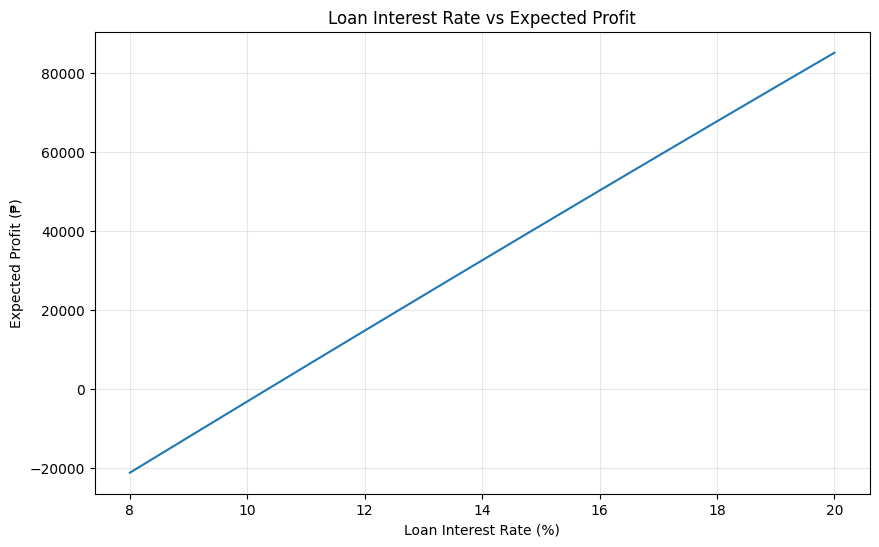

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    pricing_results["loan_rate"] * 100,
    pricing_results["expected_profit"]
)

plt.xlabel("Loan Interest Rate (%)")
plt.ylabel("Expected Profit (₱)")
plt.title(
    "Loan Interest Rate vs Expected Profit"
)

plt.grid(alpha=0.3)
plt.show()

The important idea isn't finding a magic "optimal" rate from this toy model.

It's understanding the trade-off:

$$
\boxed{
\text{Higher Rate}
\rightarrow
\text{Higher Revenue}
}
$$

but potentially:

$$
\text{Higher Rate}
\rightarrow
\text{Higher Borrower Burden}
\rightarrow
\text{Higher PD}
\rightarrow
\text{Higher Credit Loss}
$$

##Creating a scenario stress test

In [22]:
# We examine several economic scenarios.
#
# The objective is to see how credit losses change when the
# interest-rate environment changes.

stress_rates = [
    0.03,
    0.05,
    0.06,
    0.08,
    0.10,
    0.12
]

stress_results = []

for rate in stress_rates:

    stressed_pd = rate_adjusted_pd(
        baseline_pd,
        rate
    )

    expected_loss = np.sum(
        stressed_pd
        * 0.40
        * portfolio_ead
    )

    stress_results.append({
        "interest_rate": rate,
        "portfolio_pd_mean": np.mean(stressed_pd),
        "expected_loss": expected_loss
    })

stress_results = pd.DataFrame(
    stress_results
)

stress_results

,interest_rate,portfolio_pd_mean,expected_loss
0,0.03,0.078192,1.651421e+08
1,0.05,0.084704,1.788963e+08
2,0.06,0.088161,1.861972e+08
3,0.08,0.095504,2.017051e+08
4,0.10,0.103458,2.185045e+08
5,0.12,0.112075,2.367031e+08


##Plot the stress-test results

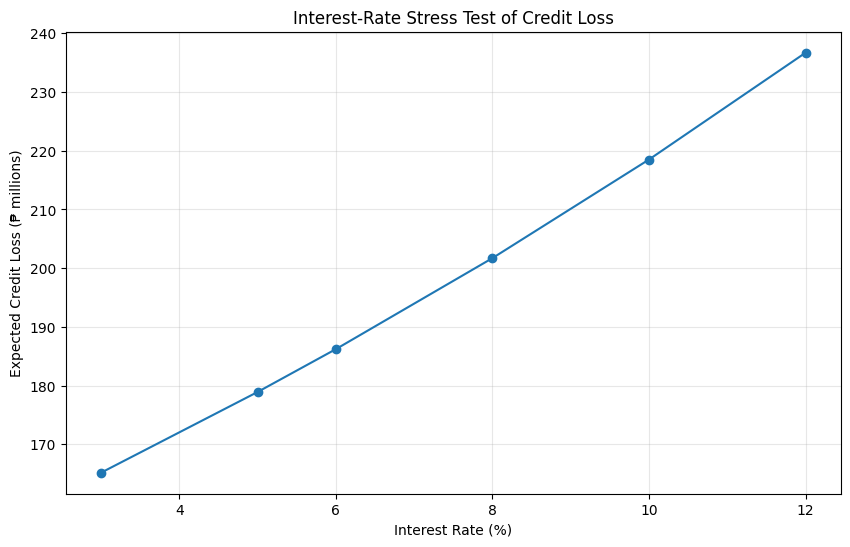

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    stress_results["interest_rate"] * 100,
    stress_results["expected_loss"] / 1_000_000,
    marker="o"
)

plt.xlabel("Interest Rate (%)")
plt.ylabel("Expected Credit Loss (₱ millions)")
plt.title(
    "Interest-Rate Stress Test of Credit Loss"
)

plt.grid(alpha=0.3)
plt.show()

##Summary

In [24]:
summary = {
    "Portfolio Size": f"₱{portfolio_ead.sum():,.0f}",

    "Number of Loans": f"{N:,}",

    "Average PD":
        f"{loan_data['predicted_pd'].mean() * 100:.2f}%",

    "Expected Credit Loss":
        f"₱{expected_loss:,.0f}",

    "95% VaR":
        f"₱{var_95:,.0f}",

    "99% VaR":
        f"₱{var_99:,.0f}",

    "95% Expected Shortfall":
        f"₱{expected_shortfall_95:,.0f}"
}

for key, value in summary.items():
    print(f"{key}: {value}")

Portfolio Size: ₱5,258,393,922
Number of Loans: 10,000
Average PD: 8.82%
Expected Credit Loss: ₱236,703,085
95% VaR: ₱212,918,266
99% VaR: ₱225,117,838
95% Expected Shortfall: ₱220,636,076
